# Green platform

## Data Recovery

Since edge sites consume electricity from the grid when local renewable generation is insufficient, we model the carbon intensity of both the edge and the cloud based on the local generation capacity and the carbon intensity of the power grid. Our study uses ERCOT and Electricty Maps data from January 1, 2024 to December 31, 2024.  

### On-site free-carbon energy

We use the ERCOT Short-Term Photovoltaic Power Forecast (STPPF) for solar generation ([Ercot](https://data.ercot.com/data-product-details/np4-745-cd)) and the ERCOT Short-Term Wind Power Forecast (STWPF) for wind generation ([Ercot](https://data.ercot.com/data-product-details/np4-732-cd)) (data does not appear to be available in France, it was collected in the U.S. as part of a collaboration with the University of Chicago). After creating a free account, for both datasets, you need to select the data for the year 2024, which means filtering the “Posted” field to show entries between January 1, 2024, and January 1, 2025. This should return 1,897,124 results, which you can then download (as a single file). The files must be respectively placed in the folders named "rawData/solar" and "rawData/wind". In addition to containing the exact values collected every hour, this data also includes hourly forecasts for energy generation over the next 72 hours.

### Carbon intensity of the grid

We use carbon intensity data from [Electricity Maps](https://www.electricitymaps.com/). They are available [here](https://app.electricitymaps.com/datasets), after creating a free account, with an academic access. Select the US-TEX-ERCO area, set the granularity to Daily, and choose the version dated February 10, 2026, then download the file for the year 2024. The document must be placed in the folder named "rawData/grid".

## Data Processing

We begin by normalizing the data we have collected. What interests us are the trend lines rather than the exact energy production values. For this purpose, we have determined two thresholds. The first, for solar panels, is based on the reasonable expectation of at least 6 hours of sunlight per day (on average over the year), and thus we must proportion our installations so that during these 6 hours, the energy generated by the solar panels is sufficient to fully power the local edge server. Thus, we can set this threshold $M_s$ as the 75th percentile. The second threshold, for wind turbines, is such that such that, on average, production is sufficient to supply half of the energy required to power the server. Thus, we can set this threshold $M_w$ as the double of the 50th percentile. Here are the normalization formulas, at hour $t$, with power generation $x$ (solar or wind), for the carbon intensity $c_{x,t}$: $$c_{x,t} = (1 - \frac{P_t}{M_x})*G_t,$$ where $P_t$ is the local renewable energie production from hour $t$ to $t+1$ and $G_t$ is the cost of the grid in kgCO2e/MWh (depending on the month).

#### Importing libraries

In [1]:
import pandas as pd
import numpy as np
import os
import csv
from copy import deepcopy
from datetime import datetime, timedelta
from collections import Counter
import matplotlib.pyplot as plt
from collections import defaultdict
from collections import deque
from glob import glob

#### Compute static monthly carbon intensity

In [2]:
def get_monthly_aci():
    # Direct path to your file
    df = pd.read_csv("rawData/grid/" + os.listdir("rawData/grid")[0])
    # Convert datetime column to real datetime
    df["datetime"] = pd.to_datetime(df["Datetime (UTC)"])
    # Extract month (YYYY-MM format)
    df["month"] = df["datetime"].dt.to_period("M")
    
    df = (df[["datetime", "Carbon intensity gCO₂eq/kWh (direct)"]].drop_duplicates().sort_values("datetime").reset_index(drop=True))
    df["id"] = df.index
    df["d"] = df["id"] % 30
    df["m"] = (df["id"] // 30)
    # Compute monthly averages
    df = df.loc[df["m"] < 12]
    df["carbon_intensity_avg"] = df.groupby("m")["Carbon intensity gCO₂eq/kWh (direct)"].mean()

    
    df = df[["m", "Carbon intensity gCO₂eq/kWh (direct)"]]
    df["m"] = df["m"].astype(str)
    G_by_month = dict(zip(df["m"], df["Carbon intensity gCO₂eq/kWh (direct)"]))

    return G_by_month

G_by_month = get_monthly_aci()
month = ["January 2024", "February 2024", "March 2024", "April 2024", "May 2024", "June 2024", "July 2024", "August 2024", "September 2024", "October 2024", "November 2024", "December 2024"]
for i in range(12):
    print(str(month[i]) + "\t\t" + str(G_by_month[str(i)]) + "\t gCO₂eq/kWh")


January 2024		376.52	 gCO₂eq/kWh
February 2024		327.43	 gCO₂eq/kWh
March 2024		218.76	 gCO₂eq/kWh
April 2024		336.52	 gCO₂eq/kWh
May 2024		294.32	 gCO₂eq/kWh
June 2024		293.51	 gCO₂eq/kWh
July 2024		269.28	 gCO₂eq/kWh
August 2024		381.98	 gCO₂eq/kWh
September 2024		385.33	 gCO₂eq/kWh
October 2024		392.63	 gCO₂eq/kWh
November 2024		213.93	 gCO₂eq/kWh
December 2024		426.44	 gCO₂eq/kWh


In [3]:
key_map = {
    "0": "January",
    "1": "February",
    "2": "March",
    "3": "April",
    "4": "May",
    "5": "June",
    "6": "July",
    "7": "August",
    "8": "September",
    "9": "October",
    "10": "November",
    "11": "December"
}

os.makedirs("Traces", exist_ok=True)

with open("Traces/Int_carb_month.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["month", "carb"])
    for key, value in G_by_month.items():
        new_key = key_map.get(key, key)
        writer.writerow([new_key, value])

#### Extract solar and wind production values

In [4]:
def get_gen_forecast(power_source, file_path, forecast_length, history_hours=6):

    file_results = []
    backfill_log = []

    # store previous forecast vectors (most recent at the right)
    # each element is a list length forecast_length
    forecast_hist = deque(maxlen=history_hours)

    dftot = pd.read_csv(file_path).sort_values(['deliveryDate', 'hourEnding'])

    if power_source == 'wind':
        keep_cols = ['postedDatetime', 'deliveryDate', 'hourEnding', 'genLoadZoneWest', 'STWPFLoadZoneWest']
        posted_date_time = 'postedDatetime'
        actual_col_name = "genLoadZoneWest"
        forecast_col_name = "STWPFLoadZoneWest"
    elif power_source == 'solar':
        keep_cols = ['postedDatetime', 'deliveryDate', 'hourEnding', 'genFarWest', 'STPPFFarWest']
        posted_date_time = 'postedDatetime'
        actual_col_name = "genFarWest"
        forecast_col_name = "STPPFFarWest"
    else:
        raise ValueError(f"Unknown power_source: {power_source}")
    
    print(len(dftot[posted_date_time].unique()))
    for postedDatetime, df in dftot.groupby(posted_date_time):
        df = df[[c for c in keep_cols if c in df.columns]].reset_index(drop=True)
        timestamp = datetime.fromisoformat(postedDatetime)
        # timestamp = datetime.strptime(f"{postedDatetime}", "%Y-%m-%dT%H:%M:%S")
        curr_date = None
        hour_ending = None
        actual_gen_value = None
        stf = []  
        
        hour_ending = int(timestamp.hour)
        if hour_ending == 0:
            hour_ending = 24
            temp = timestamp + timedelta(days = -1)
            curr_date = temp.date()
        else:
            curr_date = timestamp.date()
        match_idx = df[(df['deliveryDate'] == str(curr_date)) & (df['hourEnding'] == hour_ending)].index
        if not match_idx.empty:
            i0 = match_idx[0]
            actual_gen_value = df.loc[i0, actual_col_name]

            rows_after = df.loc[i0 + 1:]
            if forecast_col_name in rows_after.columns:
                raw = rows_after[forecast_col_name].tolist()
                stf = raw[:forecast_length]

        assert curr_date is not None, f"{power_source}: curr_date is None"
        assert hour_ending is not None, f"{power_source}: hour_ending is None"
        mv = False
        if actual_gen_value is None:
            print("Missing value")
            mv = True
        
        if not mv:
            # FIX LENGTH + MISSING VALUES USING PREVIOUS TIMESTAMPS 
            #  pad to length H with NaN so indices exist
            stf = (list(stf) + [np.nan] * forecast_length)[:forecast_length]
        
            # fill NaNs using previous forecasts, aligned by absolute hour
            # For missing index i at time t, try:
            #   from t-1: prev[i+1]
            #   from t-2: prev2[i+2]
            used = 0
            for i in range(forecast_length):
                if not (stf[i] is None or (isinstance(stf[i], float) and np.isnan(stf[i]))):
                    continue
        
                filled = False
                # look back 1..len(history)
                for k in range(1, len(forecast_hist) + 1):
                    prev = forecast_hist[-k]  # last is most recent
                    j = i + k  # shift by k hours
                    if j < forecast_length:
                        val = prev[j]
                        if not (val is None or (isinstance(val, float) and np.isnan(val))):
                            stf[i] = val
                            used += 1
                            filled = True
                            break
                # if still not filled, leave as NaN (you can choose to drop instead)
        
            n_missing_after = int(np.isnan(np.array(stf, dtype=float)).sum())
            if used > 0 or n_missing_after > 0:
                backfill_log.append({
                    "file": power_source,
                    "timestamp": timestamp,
                    "backfilled_count": used,
                    "still_missing_count": n_missing_after,
                })
        
            forecast_hist.append(stf)
        
            # check whether len(stf) == forecast_length
            if len(stf) != forecast_length:
                print(f"Warning: {file_path} has forecast_stf length {len(stf)} instead of {forecast_length}")
        
            file_results.append({
                'timestamp': timestamp,
                'date': curr_date,
                'hour_ending': hour_ending,
                'actual_gen': actual_gen_value,
                'forecast_stf': stf
            })
        else:
            file_results.append(file_results[-1])

    print(backfill_log)

    return file_results

def sequential_timestamps(file_results, start=None):
    """
    handle timestamp issue in generation raw files.
    """
    if not file_results:
        return file_results

    if start is None:
        start = min(r["timestamp"] for r in file_results if r.get("timestamp") is not None)

    start = pd.Timestamp(start).to_pydatetime()

    for i, r in enumerate(file_results):
        r["timestamp"] = start + timedelta(hours=i)
    return file_results

############ ERCOT GRID GENERATION DATA (ACTUAL) ############

forecast_length = 72 # hrs

file_results_wind_pred = get_gen_forecast('wind', "rawData/wind/" + os.listdir("rawData/wind")[0], forecast_length)
file_results_solar_pred = get_gen_forecast('solar', "rawData/solar/" + os.listdir("rawData/solar")[0], forecast_length)

file_results_wind_pred = sequential_timestamps(file_results_wind_pred)
file_results_solar_pred = sequential_timestamps(file_results_solar_pred)

# ############ ALIGN 3 DATASETS ON START/END TIMESTAMPS ############

file_results_wind_pred_sorted = sorted(file_results_wind_pred, key=lambda x: x['timestamp'])
file_results_solar_pred_sorted = sorted(file_results_solar_pred, key=lambda x: x['timestamp'])

# Start and end dates for wind generation
start_date_wind = file_results_wind_pred_sorted[0]['timestamp']
end_date_wind = file_results_wind_pred_sorted[-1]['timestamp']
# Start and end dates for solar generation
start_date_solar = file_results_solar_pred_sorted[0]['timestamp']
end_date_solar = file_results_solar_pred_sorted[-1]['timestamp']

# Align datasets of start/end dates 
common_start = max(start_date_solar, start_date_wind)
common_end = min(end_date_solar, end_date_wind)

# Keep full dict structure but align by timestamp range
aligned_wind = [
    entry for entry in file_results_wind_pred_sorted
    if common_start <= entry['timestamp'] <= common_end
]

aligned_solar = [
    entry for entry in file_results_solar_pred_sorted
    if common_start <= entry['timestamp'] <= common_end
]

"""
# Handle missing timestamp in wind data
missing_ts = pd.Timestamp('2024-05-16 15:00:00')
prev_ts = missing_ts - pd.Timedelta(hours=1)
wind_ts_to_entry = {entry['timestamp']: entry for entry in aligned_wind}
if missing_ts not in wind_ts_to_entry and prev_ts in wind_ts_to_entry:
    new_entry = deepcopy(wind_ts_to_entry[prev_ts])
    new_entry['timestamp'] = missing_ts
    aligned_wind.append(new_entry)
    aligned_wind = sorted(aligned_wind, key=lambda x: x['timestamp'])
    # print(f"Filled missing wind entry for {missing_ts} using values from {prev_ts}")
"""

# ############ EDGE RESOURCE MODEL ############
# Extract values only AFTER filtering full entries
timestamps = [entry['timestamp'] for entry in aligned_solar]
actual_solar_gen = [entry['actual_gen'] for entry in aligned_solar]
actual_wind_gen = [entry['actual_gen'] for entry in aligned_wind]

# Forecast lists (each element is a list of length H=forecast_length)
solar_forecasts = [entry["forecast_stf"] for entry in aligned_solar]
wind_forecasts  = [entry["forecast_stf"] for entry in aligned_wind]

# Create delta between actual and predicted values
timestamps = timestamps[1:]
actual_solar_gen = actual_solar_gen[1:]
actual_wind_gen = actual_wind_gen[1:]
solar_forecasts = solar_forecasts[:-1]
wind_forecasts = wind_forecasts[:-1]

sorted_actual_solar_gen = sorted(actual_solar_gen)
sorted_actual_wind_gen = sorted(actual_wind_gen)

8784
Missing value
[]
8780
[]


#### Compute threshold

In [5]:
print(len(actual_wind_gen))
L = actual_wind_gen.copy()
# avg must be greater than the average you are looking for; if possible, use the maximum value in the list 
# value must be at max, only 2 times the average
def tronc_avg(L, avg, epsilon = 0.1):
    acc = 0
    for i in range(len(L)):
        if L[i] > avg*2 or np.isnan(L[i]):
            L[i] = avg*2
        acc += L[i]
    if abs(acc / len(L) - avg) > epsilon:
        avg = tronc_avg(L, acc / len(L), epsilon)
    return avg

M_solar_base = sorted_actual_solar_gen[int(len(sorted_actual_solar_gen)*0.75)] 
M_wind_base = tronc_avg(L, sorted_actual_wind_gen[int(len(sorted_actual_wind_gen)*0.95)])*2
M_wind_base2 = sorted_actual_wind_gen[int(len(sorted_actual_wind_gen)*0.5)]*2
Max_solar_base = max(actual_solar_gen) # max_solar_gen_over_year
Max_wind_base = max(L)# max_wind_gen_over_year

print("Servers should be fully powered for an average of 6h/day")
print("Threshold solar = ", M_solar_base)
print("On average, the servers should be running at half capacity")
print("Threshold wind = ", M_wind_base)
print("Threshold wind = ", M_wind_base2)
print('Maximum solar generation = ', Max_solar_base)
print('Maximum wind generation = ', Max_wind_base)

8778
Servers should be fully powered for an average of 6h/day
Threshold solar =  2727.54
On average, the servers should be running at half capacity
Threshold wind =  17814.205342115703
Threshold wind =  31549.88
Maximum solar generation =  8402.65
Maximum wind generation =  17814.205342115703


#### Compute carbon intensity values

In [6]:
def group_by_month(timestamps, solar_actual_values, wind_actual_values, solar_forecasts, wind_forecasts, M_solar, M_wind):
    """
    Returns:
      monthly[month] = {
        "timestamps": [ts0, ts1, ...],
        "actual": {
          "solar": [..], "wind": [..]
        },
        "forecast": {
          "solar": [[h1..hH], ...], "wind": [[h1..hH], ...]
        }
      }
    """
    def clamp01(x):
        if x is None or (isinstance(x, float) and np.isnan(x)):
            return np.nan
        if pd.isna(x):
            return np.nan
        return min(max(float(x), 0.0), 1.0)

    monthly = defaultdict(lambda: {
        "timestamps": [],
        "actual":   {"solar": [], "wind": []},
        "forecast": {"solar": [], "wind": []},
    })

    for ts, sa, wa, sf, wf in zip(timestamps, solar_actual_values, wind_actual_values, solar_forecasts, wind_forecasts):
        month = pd.Timestamp(ts).strftime("%Y-%m") # e.g. "2024-05"

        # Normalize each generation signal to its own maximum
        s_norm = clamp01(float(sa) / M_solar) if M_solar > 0 else np.nan  # shape (0–1)
        w_norm = clamp01(float(wa) / M_wind)  if M_wind > 0 else np.nan

        # normalize forecasts (same normalization as actuals)
        # Ensure correct length H
        sf = list(sf) if sf is not None else []
        wf = list(wf) if wf is not None else []

        # pad/trim to forecast_length
        sf = (sf + [np.nan] * forecast_length)[:forecast_length]
        wf = (wf + [np.nan] * forecast_length)[:forecast_length]

        s_fc_norm = [clamp01(x / M_solar) if (M_solar > 0 and not pd.isna(x)) else np.nan for x in sf]
        w_fc_norm = [clamp01(x / M_wind)  if (M_wind > 0 and not pd.isna(x)) else np.nan for x in wf]

        monthly[month]["timestamps"].append(pd.Timestamp(ts))
        monthly[month]["actual"]["solar"].append(s_norm)
        monthly[month]["actual"]["wind"].append(w_norm)
        
        monthly[month]["forecast"]["solar"].append(s_fc_norm)   # shape: T_month x H
        monthly[month]["forecast"]["wind"].append(w_fc_norm)
        """
        monthly[month]["actual"]["solar"].append(sa)
        monthly[month]["actual"]["wind"].append(wa)
        
        monthly[month]["forecast"]["solar"].append(sf)   # shape: T_month x H
        monthly[month]["forecast"]["wind"].append(wf)
        """
    return monthly

monthly_generation = group_by_month(
    timestamps,
    actual_solar_gen,
    actual_wind_gen,
    solar_forecasts,
    wind_forecasts,
    M_solar_base,
    M_wind_base)

def compute_carbon_traces(monthly_generation, forecast_length=72):
    """
    monthly_generation[month] = {
      "timestamps": [...],
      "actual":   {"solar": [...], "wind": [...]},          # length T
      "forecast": {"solar": [[...],...], "wind": [[...],...]}  # T x H
    }
    
    Returns:
      carbon_monthly[month] = {
        "timestamps": [...],
        "actual":   {"solar": [...], "wind": [...]},         # length T
        "forecast": {"solar": [[...],...], "wind": [[...],...]} # T x H
      }
    """
    def carbon_from_g(g):
        if pd.isna(g):
            return np.nan
        return float(g)
        
    carbon_monthly = {}

    for month, gen in monthly_generation.items():
        # get data: actual + forecast 
        actual = gen["actual"]
        fcst = gen["forecast"]
        ts_list = gen.get("timestamps", [])

        # actual carbon (length T)
        carbon_actual = {
            "solar": [carbon_from_g(g) for g in actual["solar"]],
            "wind":  [carbon_from_g(g) for g in actual["wind"]]
        }

        # forecast carbon (T x H) 
        carbon_forecast = {"solar": [], "wind": []}

        for solar_row, wind_row in zip(fcst["solar"], fcst["wind"]):
            # safety: pad/trim each row to forecast_length
            solar_row = (list(solar_row) + [np.nan] * forecast_length)[:forecast_length]
            wind_row  = (list(wind_row)  + [np.nan] * forecast_length)[:forecast_length]

            carbon_forecast["solar"].append([carbon_from_g(g) for g in solar_row])
            carbon_forecast["wind"].append( [carbon_from_g(g) for g in wind_row])

        carbon_monthly[month] = {
            "timestamps": ts_list,
            "actual": carbon_actual,
            "forecast": carbon_forecast,
        }

    return carbon_monthly

carbon_monthly = compute_carbon_traces(monthly_generation, forecast_length)

#### Write files

In [7]:
def write_monthly_files_predicted_with_actual(monthly_generation, carbon_monthly, output_root, forecast_length=72):
    """
    Write 2 CSV files per month with actual and predicted:
      carbon_solar_only_{scale}.csv
      carbon_wind_only_{scale}.csv

    Each CSV row: timestamp, actual, h1, ..., hH
    Shape: T rows, (H+2) columns including timestamp+actual
    """
    os.makedirs(output_root, exist_ok=True)

    # Map edge model -> file prefix and carbon_monthly key
    models = [
        ("solar", "carbon_solar_only"),
        ("wind",  "carbon_wind_only")]

    header = ["timestamp", "actual"] + [f"h{i}" for i in range(1, forecast_length + 1)]

    # which filename to use per model
    def out_name(month_dir, model_key):
        if model_key == "solar":
            return os.path.join(month_dir, f"carbon_solar_only.csv")
        elif model_key == "wind":
            return os.path.join(month_dir, f"carbon_wind_only.csv")
        else:
            raise ValueError(f"Unknown model_key: {model_key}")

    for month in monthly_generation.keys():
        carb_month = carbon_monthly.get(month)
        if carb_month is None:
            continue

        ts_list = carb_month.get("timestamps", [])
        if not ts_list:
            continue

        month_dir = os.path.join(output_root, month)
        os.makedirs(month_dir, exist_ok=True)

        for model_key, file_prefix in models:
            actual_list = carb_month["actual"][model_key] # length T
            forecast_ll = carb_month["forecast"][model_key] # T x H

            T = len(ts_list)
            if len(actual_list) != T or len(forecast_ll) != T:
                raise ValueError(
                    f"{month} {model_key}: length mismatch "
                    f"timestamps={T}, actual={len(actual_list)}, forecast_rows={len(forecast_ll)}"
                )

            # out_path = os.path.join(month_dir, f"{file_prefix}_{scale}.csv")
            out_path = out_name(month_dir, model_key)

            with open(out_path, "w", newline="") as f:
                writer = csv.writer(f)
                writer.writerow(header)

                save_actual = f"{float(0.5):.4f}"

                for ts, actual_val, row in zip(ts_list, actual_list, forecast_ll):
                    # pad/trim forecast row to forecast_length
                    row = (list(row) + [np.nan] * forecast_length)[:forecast_length]

                    ts_str = pd.Timestamp(ts).isoformat()

                    # writer.writerow([ts_str, actual_val] + row)
                    def fmt(x): 
                        if x is None or (isinstance(x, float) and np.isnan(x)):
                            return ""
                        return f"{float(x):.4f}" # format to 4 decimal places
                    def fmt_actual(x): 
                        if x is None or (isinstance(x, float) and np.isnan(x)):
                            return save_actual
                        return f"{float(x):.4f}" # format to 4 decimal places

                    save_actual = fmt_actual(actual_val)
                    writer.writerow(
                        [ts_str, save_actual] + [fmt(x) for x in row]
                    )

def write_files_actual(monthly_generation, carbon_monthly, output_root):
    """
    Write 1 CSV files for year with actual:
      carbon_solar_only_{scale}.csv
      carbon_wind_only_{scale}.csv

    Each CSV row: timestamp, actual
    Shape: T rows, 2 columns timestamp+actual
    """
    os.makedirs(output_root, exist_ok=True)

    # Map edge model -> file prefix and carbon_monthly key
    models = [
        ("solar", "carbon_solar_only"),
        ("wind",  "carbon_wind_only")]

    header = ["timestamp", "actual"]
    for model_key, file_prefix in models:
        out_path = os.path.join(output_root, file_prefix)
        os.makedirs(output_root, exist_ok=True)
        with open(out_path, "w", newline="") as f:
            writer = csv.writer(f)
            writer.writerow(header)
    
        for month in monthly_generation.keys():
            carb_month = carbon_monthly.get(month)
            if carb_month is None:
                continue
    
            ts_list = carb_month.get("timestamps", [])
            if not ts_list:
                continue


            actual_list = carb_month["actual"][model_key] # length T
        

            T = len(ts_list)
            if len(actual_list) != T:
                raise ValueError(
                    f"{month} {model_key}: length mismatch "
                    f"timestamps={T}, actual={len(actual_list)}, forecast_rows={len(forecast_ll)}"
                )

            with open(out_path, "a", newline="") as f:
                writer = csv.writer(f)

                save_actual = f"{float(0.5):.4f}"

                for ts, actual_val in zip(ts_list, actual_list):
                    # pad/trim forecast row to forecast_length
                    ts_str = pd.Timestamp(ts).isoformat()

                    # writer.writerow([ts_str, actual_val] + row)
                    def fmt(x): 
                        if x is None or (isinstance(x, float) and np.isnan(x)):
                            return save_actual
                        return f"{float(x):.4f}" # format to 4 decimal places

                    save_actual = fmt(actual_val)
                    writer.writerow(
                        [ts_str, save_actual]
                    )

output_root = "Traces/edgeModelPredicted"

write_monthly_files_predicted_with_actual(
    monthly_generation,
    carbon_monthly,
    output_root,
    forecast_length)

output_root = "Traces/edgeModelActual"

write_files_actual(
    monthly_generation,
    carbon_monthly,
    output_root)

## Some figures to visualize the data

### Real values

In [8]:
dataset = glob("Traces/edgeModelPredicted/**/*.csv", recursive=True)
os.makedirs("Figures", exist_ok=True)
df_list = []
for i, file in enumerate(dataset):
    df = pd.read_csv(file)
    df["source_file"] = os.path.basename(file)
    df_list.append(df)

dfset = pd.concat(df_list, ignore_index=True)

dfid = (dfset[["timestamp"]].drop_duplicates().sort_values("timestamp").reset_index(drop=True))

dfid["id"] = dfid.index
dfid["h"] = dfid["id"] % 24
dfid["d"] = (dfid["id"] // 24) % 30
dfid["m"] = dfid["id"] // (24 * 30)

dfid = dfid.merge(dfset, on="timestamp")
dfid = dfid[["id", "h", "d", "m", "source_file", "actual"]]

def update_source_file(df):
    df = df.copy()
    df["name"] = df["source_file"].str.extract(r'(solar|wind)')
    return df

dfname = update_source_file(dfid)

dfsolar = (dfname[dfname["name"] == "solar"].rename(columns={"actual": "solar"})[["id", "h", "d", "m", "solar"]])

dfwind = (dfname[dfname["name"] == "wind"].rename(columns={"actual": "wind"})[["id", "h", "d", "m", "wind"]])

dffinal = pd.merge(dfsolar, dfwind, on=["id", "h", "d", "m"])

print(dffinal.head())
print(dffinal["m"].unique())

   id  h  d  m  solar    wind
0   0  0  0  0    0.0  0.4899
1   1  1  0  0    0.0  0.4708
2   2  2  0  0    0.0  0.4520
3   3  3  0  0    0.0  0.4081
4   4  4  0  0    0.0  0.3173
[ 0  1  2  3  4  5  6  7  8  9 10 11 12]


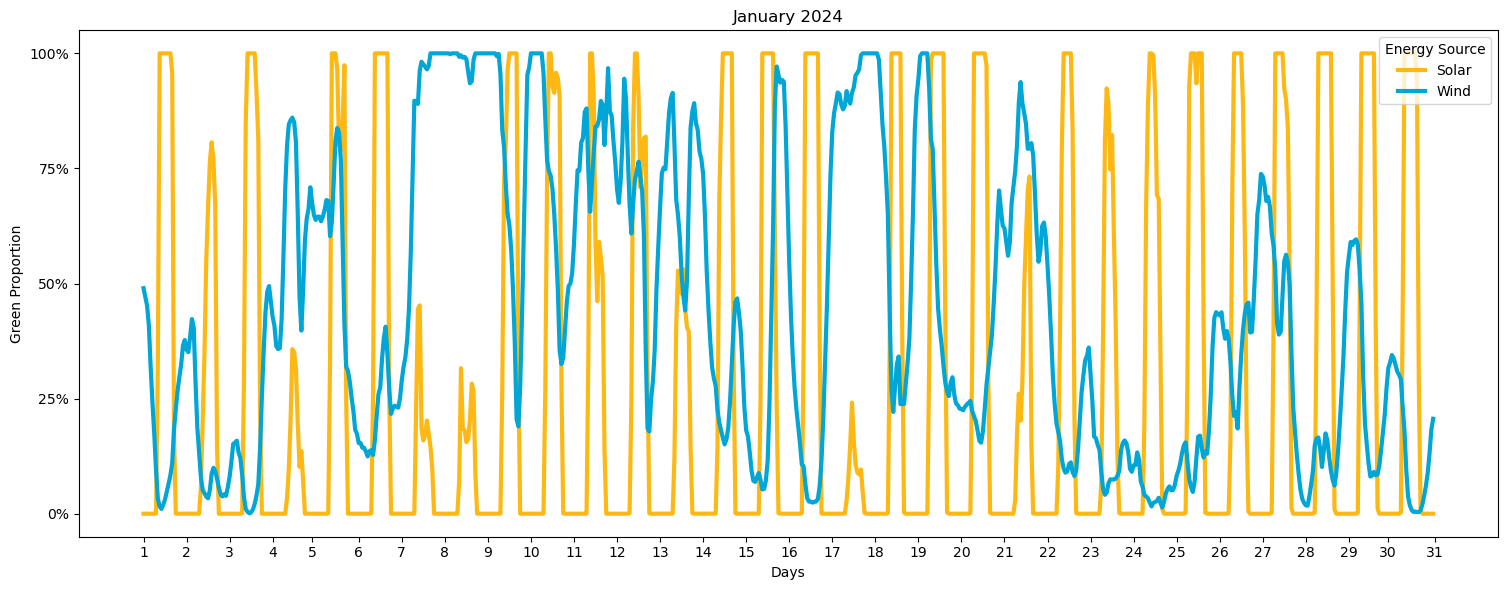

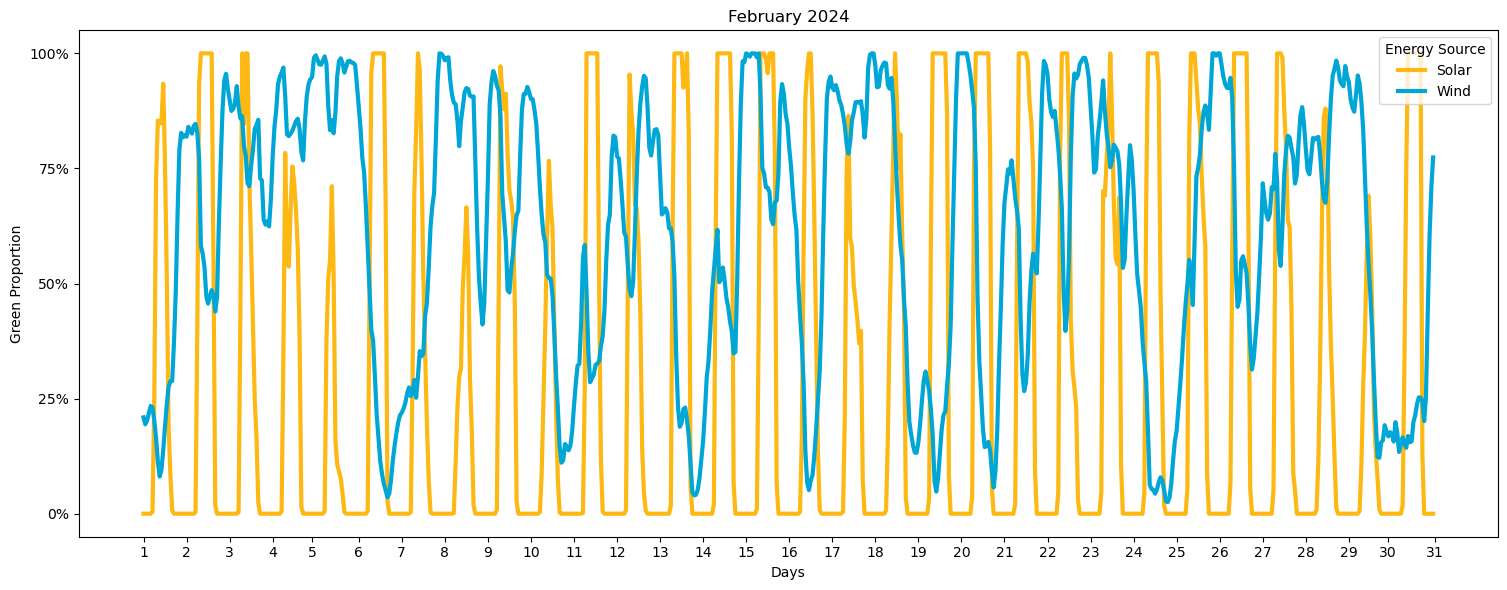

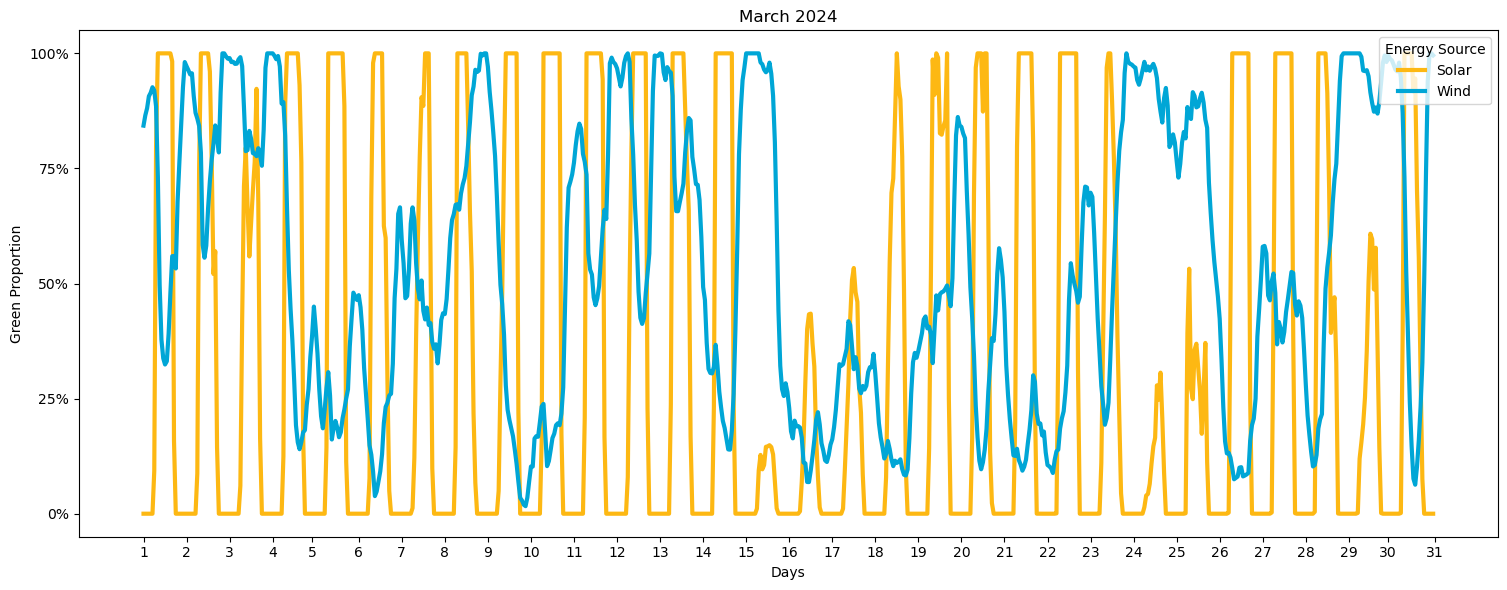

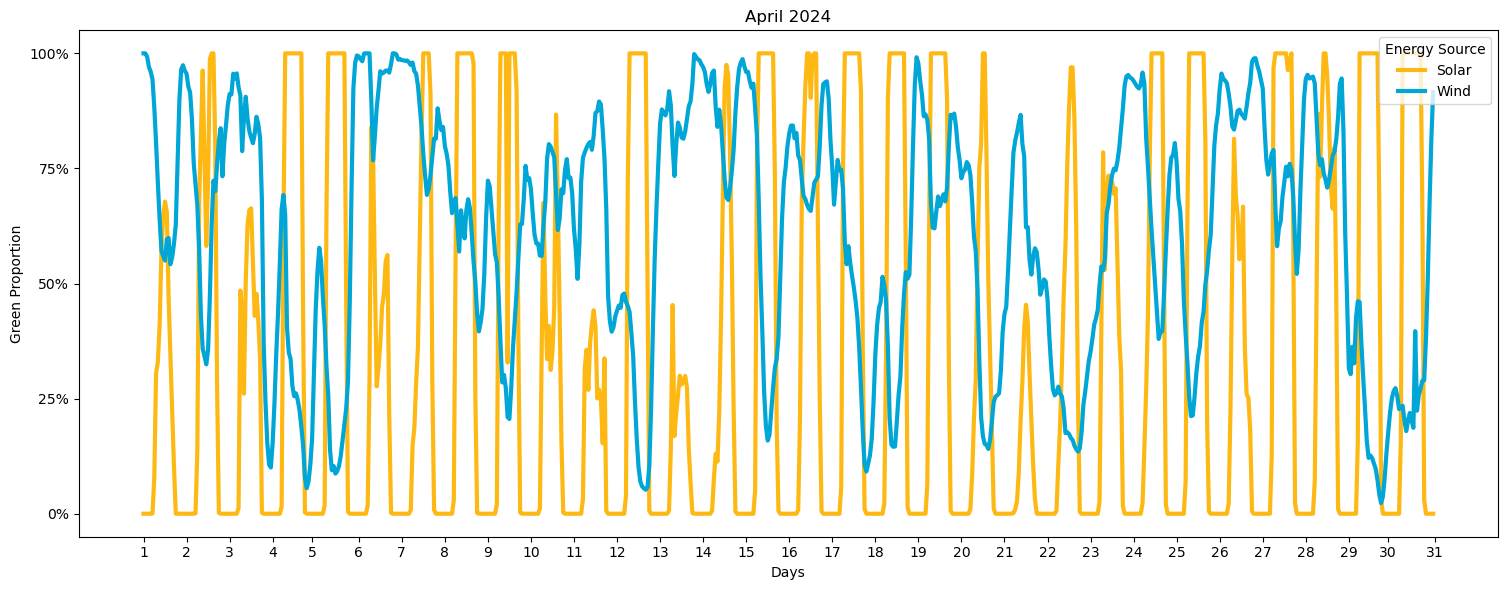

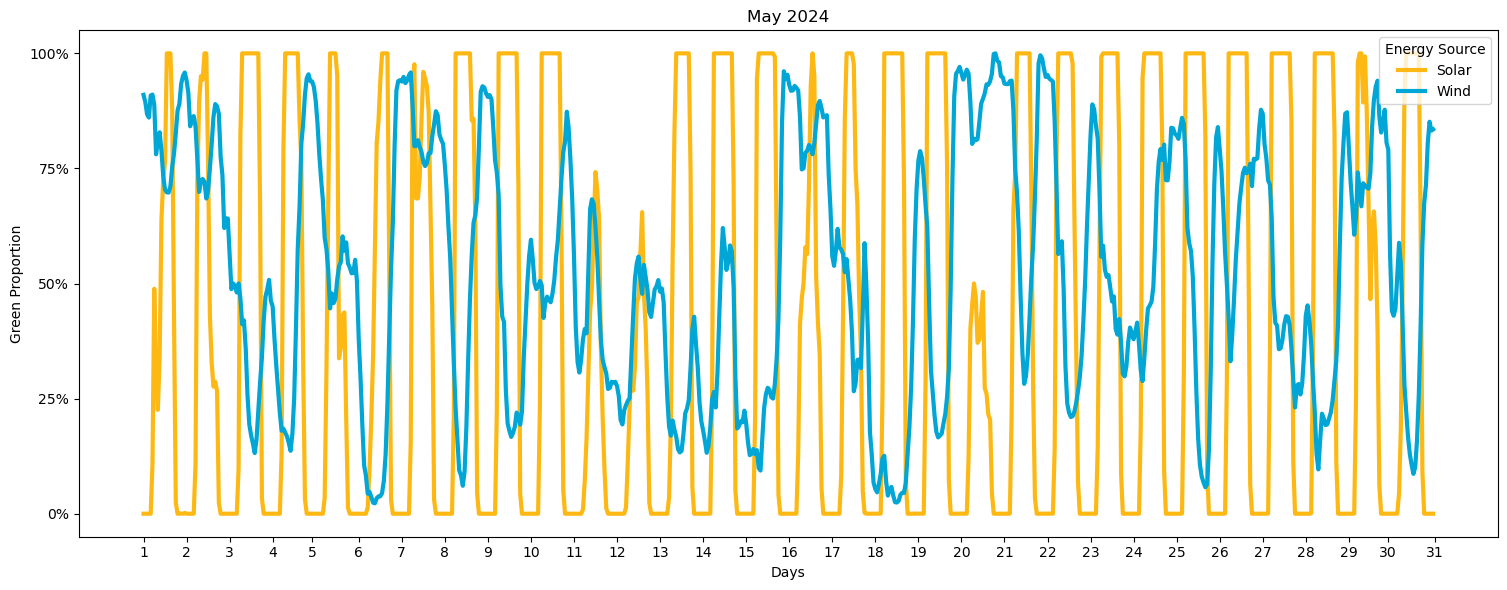

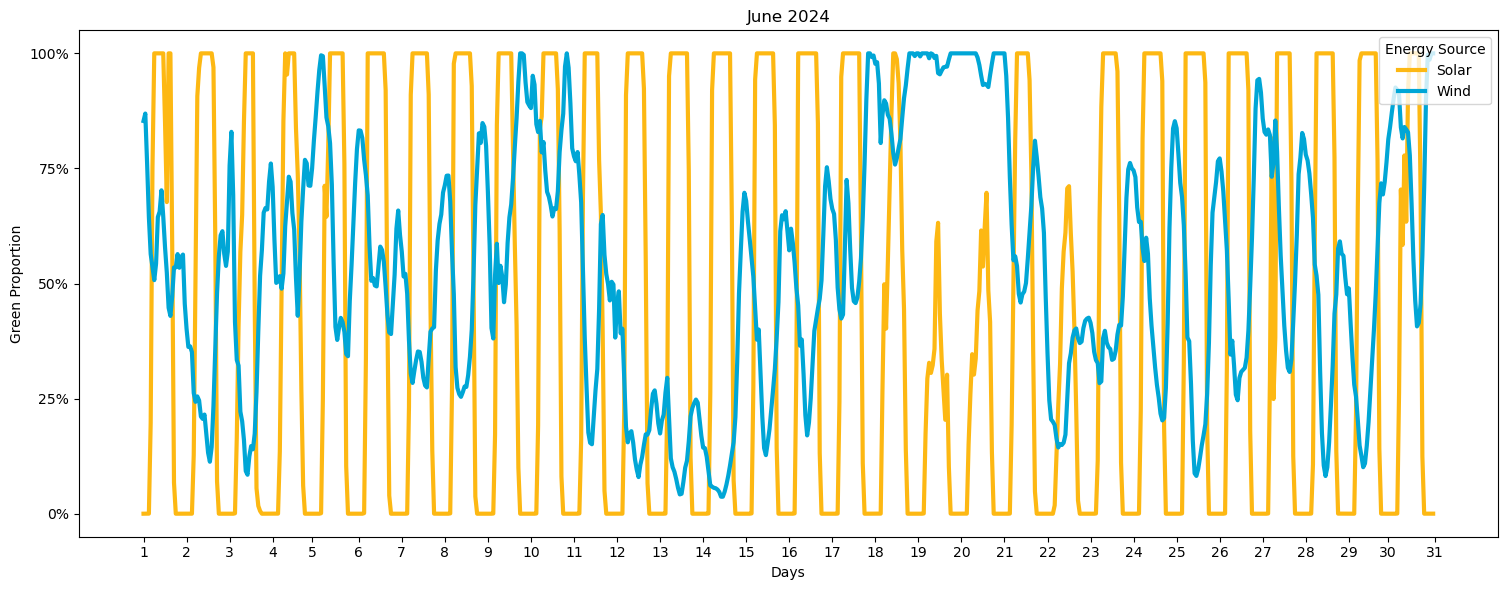

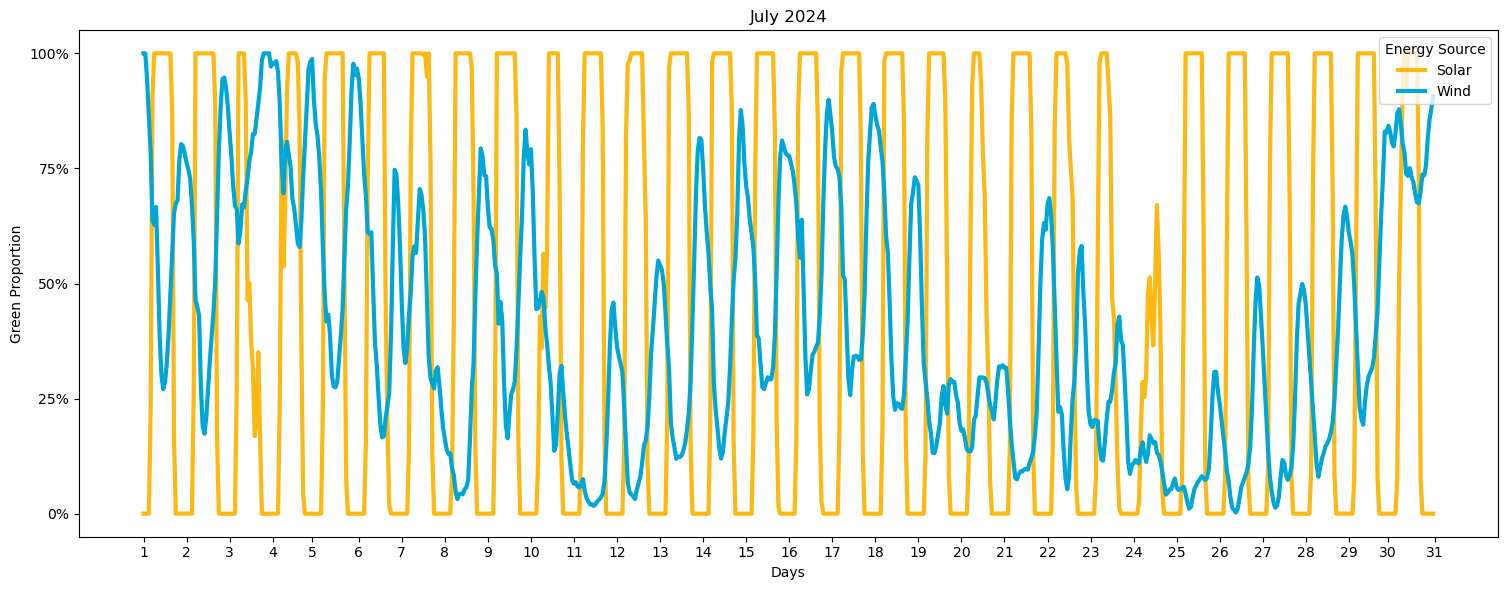

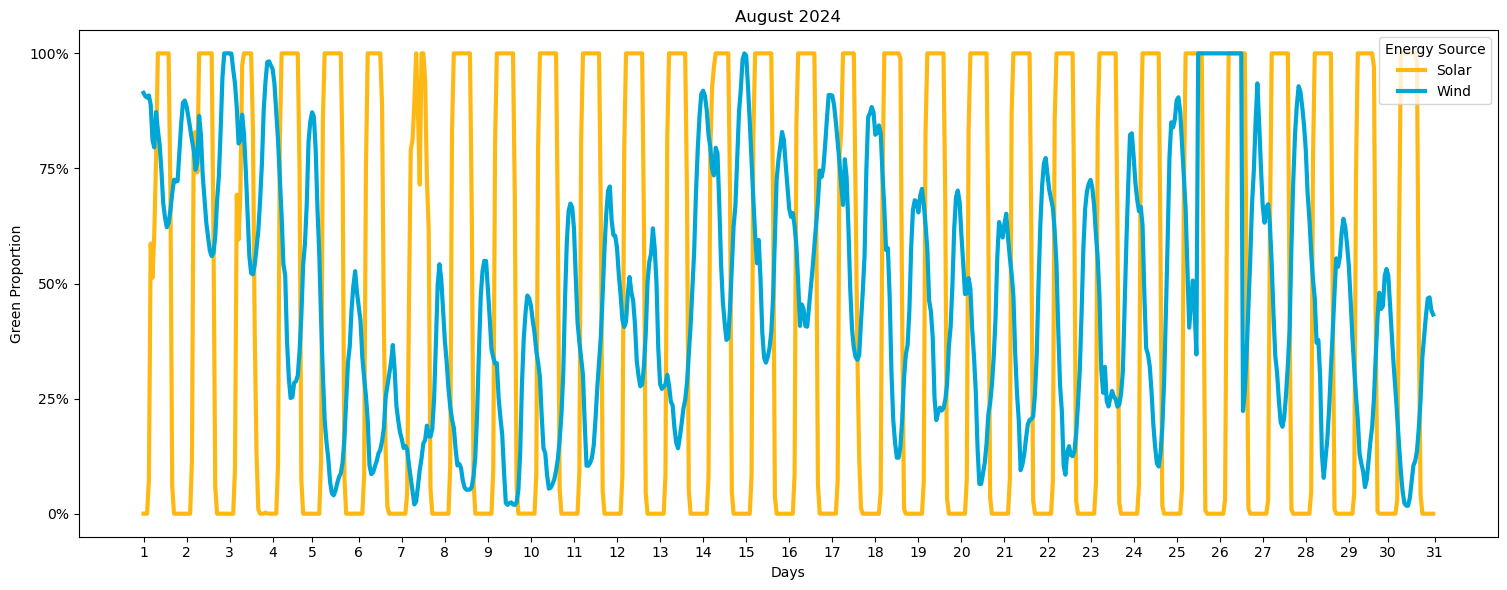

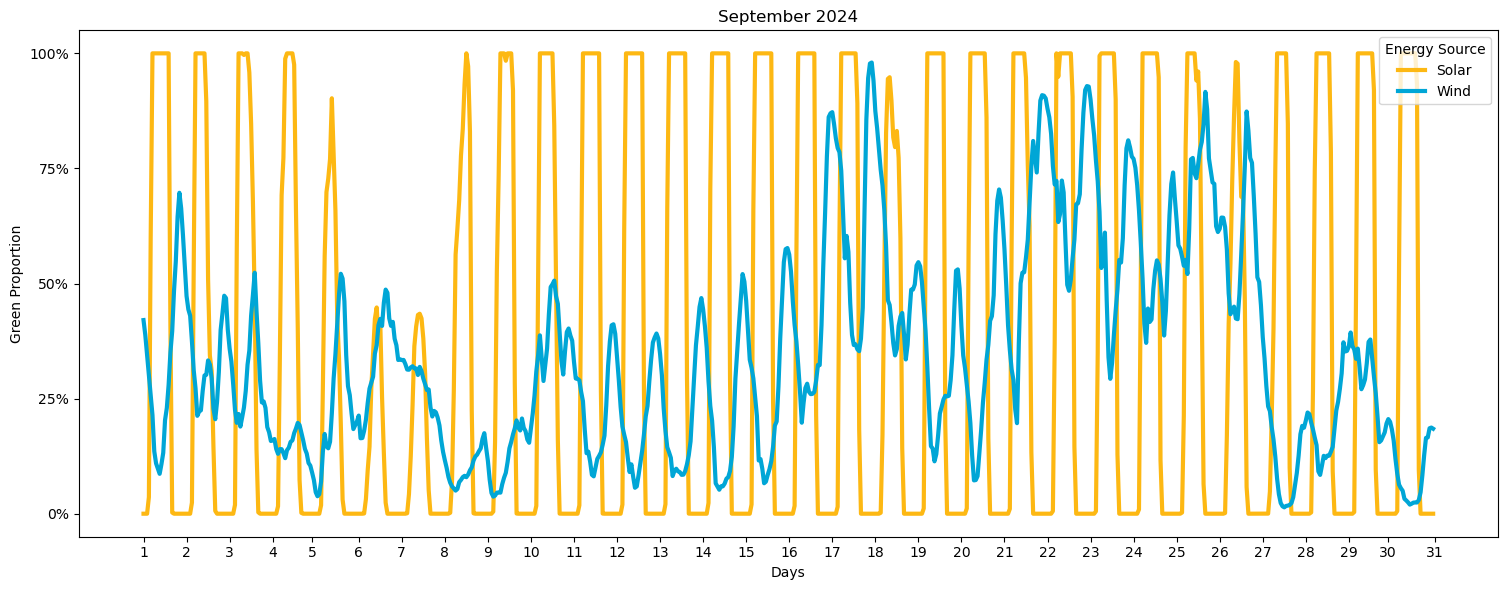

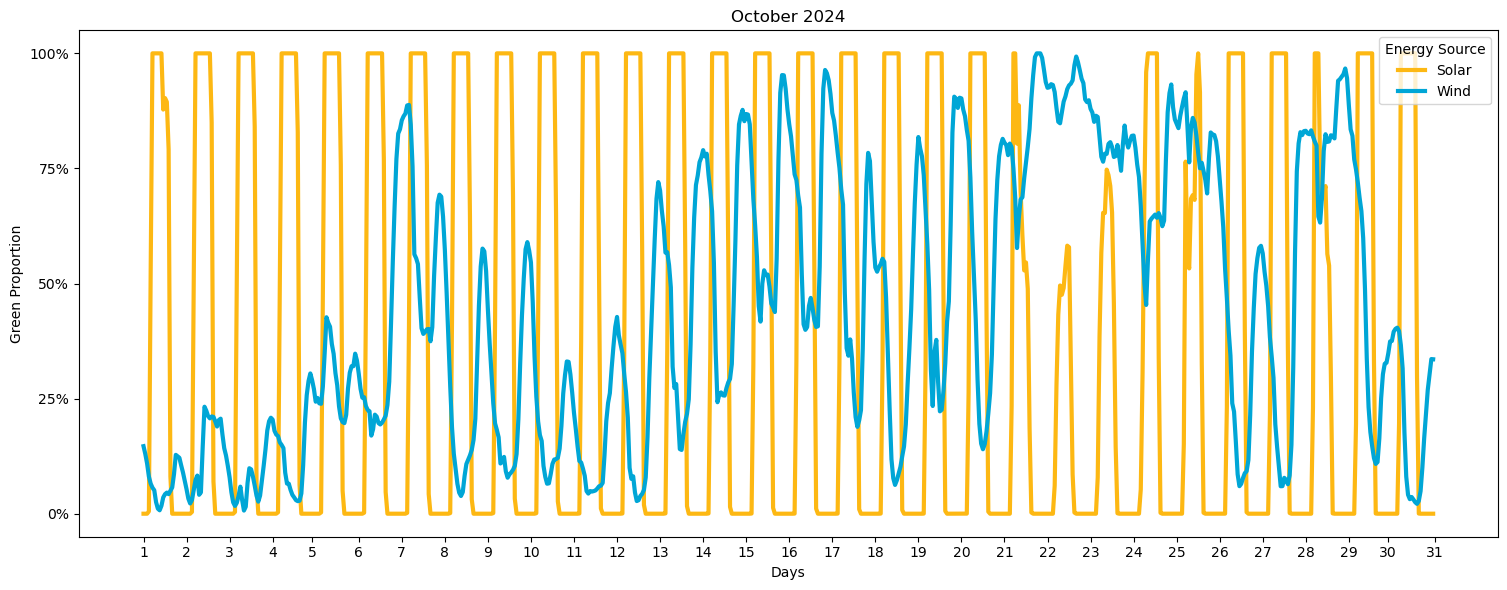

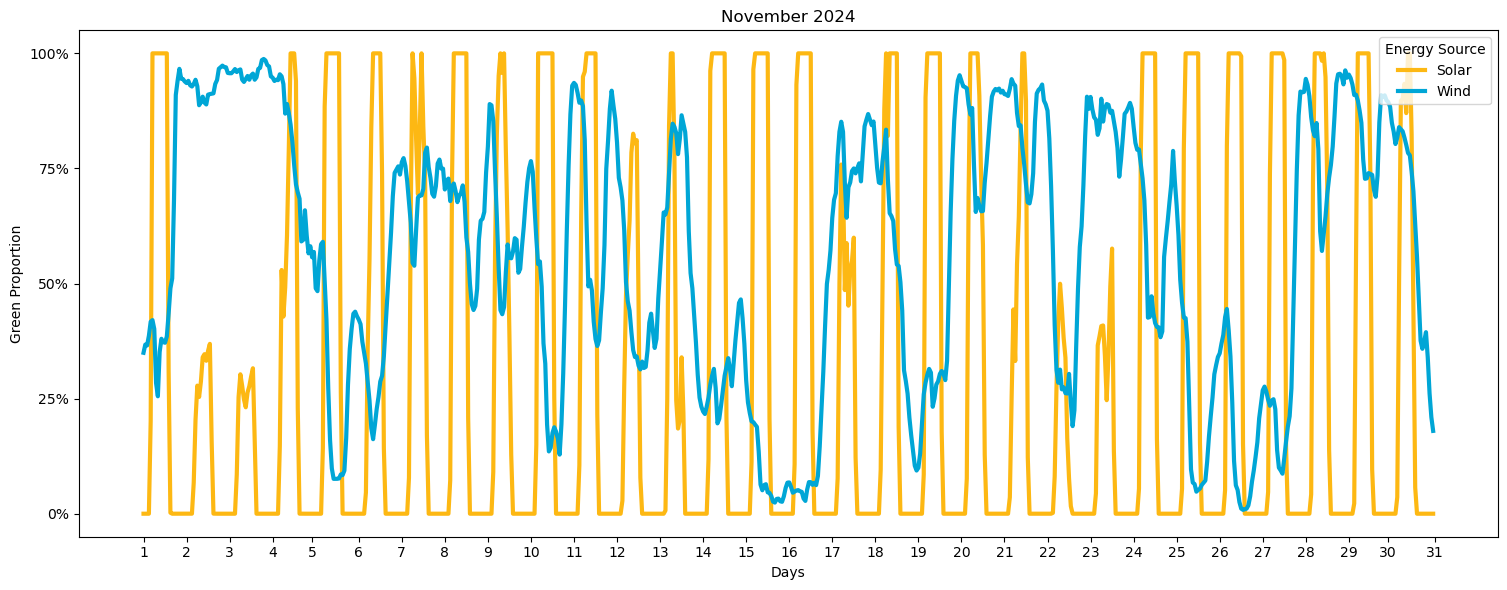

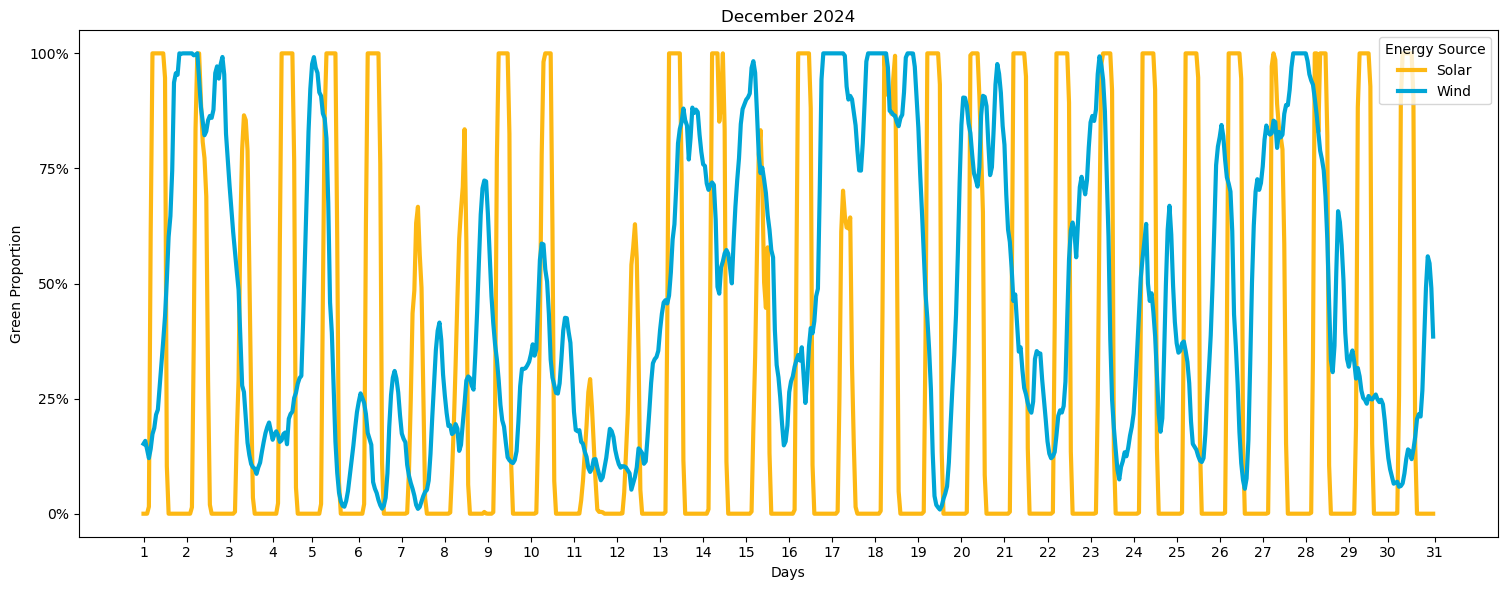

In [9]:
palette = {"solar": "#FDB813", "wind": "#00A6D6"}

month = ["January 2024", "February 2024", "March 2024", "April 2024", "May 2024", "June 2024", "July 2024", "August 2024", "September 2024", "October 2024", "November 2024", "December 2024"]

for m in range(12):
    dfplot = dffinal[dffinal["m"] == m]
    
    plt.figure(figsize=(15, 6))
    
    plt.plot(dfplot["id"]%720, dfplot["solar"], label="Solar", color = palette["solar"], linewidth = 3)
    plt.plot(dfplot["id"]%720, dfplot["wind"], label="Wind", color = palette["wind"], linewidth = 3)
    
    plt.xlabel("Days")
    plt.ylabel("Green Proportion")
    plt.title(month[m])
    plt.tight_layout()
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles, ["Solar", "Wind"], title="Energy Source", loc="upper right")
    plt.xticks([0, 24, 48, 72, 94, 120, 144, 168, 192, 216, 240, 264, 288, 312, 336, 360, 384, 408, 432,
                                  456, 480, 504, 528, 552, 576, 600, 624, 648, 672, 694, 720], 
               [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24,
                                25, 26, 27, 28, 29, 30, 31])
    plt.yticks([0, 0.25, 0.5, 0.75, 1], ["0%", "25%", "50%", "75%", "100%"])
    plt.savefig("Figures/" + month[m] + ".pdf")
    plt.show()

### Prediction values

In [10]:
dataset = glob("Traces/edgeModelPredicted/**/*.csv", recursive=True)
df_list = []
for i, file in enumerate(dataset):
    df = pd.read_csv(file)
    df["source_file"] = os.path.basename(file)
    df_list.append(df)

dfset = pd.concat(df_list, ignore_index=True)

dfid = (dfset[["timestamp"]].drop_duplicates().sort_values("timestamp").reset_index(drop=True))

dfid["id"] = dfid.index
dfid["h"] = dfid["id"] % 24
dfid["d"] = (dfid["id"] // 24) % 30
dfid["m"] = dfid["id"] // (24 * 30)

dfid = dfid.merge(dfset, on="timestamp")

def update_source_file(df):
    df = df.copy()
    df["name"] = df["source_file"].str.extract(r'(solar|wind)')
    return df

dfname = update_source_file(dfid)

dfwind = dfname[dfname["name"] == "wind"]

print(dfwind.head())
print(dfwind["m"].unique())

             timestamp  id  h  d  m  actual      h1      h2      h3      h4  \
1  2024-01-01T01:55:39   0  0  0  0  0.4899  0.4941  0.4346  0.3972  0.3583   
3  2024-01-01T02:55:39   1  1  0  0  0.4708  0.4785  0.4221  0.3689  0.3148   
5  2024-01-01T03:55:39   2  2  0  0  0.4520  0.4570  0.4036  0.3493  0.2874   
7  2024-01-01T04:55:39   3  3  0  0  0.4081  0.4231  0.3563  0.2854  0.2097   
9  2024-01-01T05:55:39   4  4  0  0  0.3173  0.3325  0.2595  0.1924  0.1271   

   ...     h65     h66     h67     h68     h69     h70     h71     h72  \
1  ...  0.0354  0.0818  0.1268  0.1729  0.2315  0.3214  0.4018  0.4539   
3  ...  0.0681  0.1143  0.1616  0.2182  0.3013  0.3879  0.4457  0.4671   
5  ...  0.1143  0.1616  0.2182  0.3013  0.3879  0.4457  0.4671  0.4711   
7  ...  0.1616  0.2141  0.2880  0.3670  0.4241  0.4479  0.4548  0.4784   
9  ...  0.2236  0.2901  0.3594  0.4072  0.4284  0.4380  0.4624  0.4826   

            source_file  name  
1  carbon_wind_only.csv  wind  
3  carbon_wind_o

In [11]:
# palette = {"wind": "#000000", "wind0": "#00D5FB", "wind12": "#00AED6", "wind24": "#009DE4", "wind36": "#006BC4", "wind48": "#003059"}
# palette = {"wind": "#000000", "wind0": "#90CBF9", "wind12": "#41A7F5", "wind24": "#1A8AE5", "wind36": "#1065C0", "wind48": "#0747A1"}
# palette = {"wind": "#000000", "wind0": "#CCFF00", "wind12": "#FF9966", "wind24": "#CC0033", "wind36": "#FF33FF", "wind48": "#990099"}

# dftemp = dfwind[dfwind["m"] == 0]
# dfplot = dftemp[dftemp["d"] < 3].sort_values("timestamp").reset_index(drop=True)
# dfwind0 = dfplot["actual"]
# for h in range(1, 72):
#     dfwind0[h] = float(dfplot.at[0, "h"+str(h)])
# dfwind12 = dfplot["actual"]
# for h in range(1, 60):
#     dfwind12[h+12] = float(dfplot.at[12, "h"+str(h)])
# dfwind24 = dfplot["actual"]
# for h in range(1, 48):
#     dfwind24[h+24] = float(dfplot.at[24, "h"+str(h)])
# dfwind36 = dfplot["actual"]
# for h in range(1, 36):
#     dfwind36[h+36] = float(dfplot.at[36, "h"+str(h)])
# dfwind48 = dfplot["actual"]
# for h in range(1, 24):
#     dfwind48[h+48] = float(dfplot.at[48, "h"+str(h)])
# 
# plt.figure(figsize=(12, 7))
#     
# plt.plot(dfplot["id"], dfwind0, label="Wind0", color = palette["wind0"], linewidth = 4, linestyle = "dashed")
# plt.plot(dfplot["id"], dfwind12, label="Wind12", color = palette["wind12"], linewidth = 4, linestyle = "dotted")
# plt.plot(dfplot["id"], dfwind24, label="Wind24", color = palette["wind24"], linewidth = 4, linestyle = "dotted")
# plt.plot(dfplot["id"], dfwind36, label="Wind36", color = palette["wind36"], linewidth = 4, linestyle = "dotted")
# plt.plot(dfplot["id"], dfwind48, label="Wind48", color = palette["wind48"], linewidth = 4, linestyle = "dotted")
# plt.plot(dfplot["id"], dfplot["actual"], label="Wind", color = palette["wind"], linewidth = 4)
# 
# plt.xlabel("Days")
# plt.ylabel("Green Proportion")
# plt.title("Predictions")
# plt.tight_layout()
# handles, labels = plt.gca().get_legend_handles_labels()
# plt.legend(handles, ["Wind0", "Wind12", "Wind24", "Wind36", "Wind48", "Wind"], title="Predictions", loc="upper right")
# plt.xticks([0, 24, 48, 72], [1, 2, 3, 4])
# plt.yticks([0, 0.25, 0.5, 0.75, 1], ["0%", "25%", "50%", "75%", "100%"])
# plt.savefig("Figures/predictionsV1.pdf")
# plt.show()

In [12]:
dftemp = dfwind[dfwind["m"] == 0]
dfh = dftemp[dftemp["d"] < 8].sort_values("timestamp").reset_index(drop=True)
res = []
for i in {1, 3, 6, 12, 24, 48, 72}:
    tempres = []
    for j in range(72, len(dfh)):
        tempres.append(float(dfh.at[j-i+1, "h"+str(i)]))
    res.append(tempres)


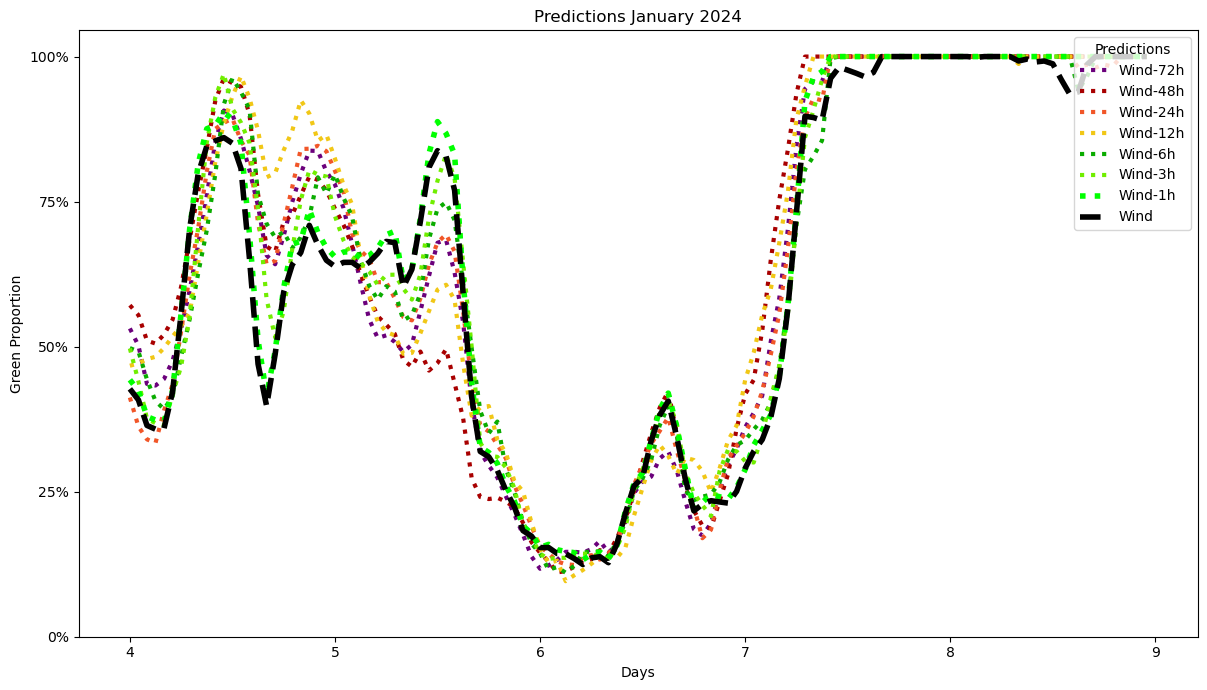

In [13]:
palette = {"wind": "#000000", "wind1": "#00FF00", "wind3": "#70EE00", "wind6": "#0AAC00", 
           "wind12": "#F1C716", "wind24": "#F15628", "wind48": "#A80000", "wind72": "#6B007B"}

dfplot = dfh[dfh["d"] > 2]

plt.figure(figsize=(12, 7))


plt.plot(dfplot["id"], res[6], label="Wind-72h", color = palette["wind72"], linewidth = 3, linestyle = "dotted")
plt.plot(dfplot["id"], res[5], label="Wind-48h", color = palette["wind48"], linewidth = 3, linestyle = "dotted")
plt.plot(dfplot["id"], res[4], label="Wind-24h", color = palette["wind24"], linewidth = 3, linestyle = "dotted")
plt.plot(dfplot["id"], res[3], label="Wind-12h", color = palette["wind12"], linewidth = 3, linestyle = "dotted")
plt.plot(dfplot["id"], res[2], label="Wind-6h", color = palette["wind6"], linewidth = 3, linestyle = "dotted")
plt.plot(dfplot["id"], res[1], label="Wind-3h", color = palette["wind3"], linewidth = 3, linestyle = "dotted")
plt.plot(dfplot["id"], res[0], label="Wind-1h", color = palette["wind1"], linewidth = 4, linestyle = "dotted")
plt.plot(dfplot["id"], dfplot["actual"], label="Wind", color = palette["wind"], linewidth = 4, linestyle = "dashed")

plt.xlabel("Days")
plt.ylabel("Green Proportion")
plt.title("Predictions January 2024")
plt.tight_layout()
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, labels, title="Predictions", loc="upper right")
plt.xticks([72, 96, 120, 144, 168, 192], [4, 5, 6, 7, 8, 9])
plt.yticks([0, 0.25, 0.5, 0.75, 1], ["0%", "25%", "50%", "75%", "100%"])
plt.savefig("Figures/predictionsV2.pdf")
plt.show()

## Appendix

### From power generation to carbon cost

To obtain the carbon cost of the edge server, we assume that edge sites are equipped with Dell PowerEdge XR5610 servers, which are designed for edge deployments (see [Dell PowerEdge Edge Servers](https://www.dell.com/en-us/shop/cty/pdp/spd/poweredge-xr5610?ref=explore+poweredge-edge-servers\#compare-module). Since we focus on scientific computing workloads with high utilization, we model server power draw at $100\%$ utilization. Based on the [SPECpower benchmark](https://www.spec.org/power_ssj2008/results/res2023q3/power_ssj2008-20230724-01289.html), the maximum power draw of a Dell PowerEdge XR5610 server is $256\,W$, and the idle power draw is $124\,W$. Thus, we model the dynamic power consumption as $132\,W$, representing the incremental power draw when the server is active.

Let $c_{x,t}$ denote the carbon intensity during the time period (in kgCO2e/MWh).
The carbon cost, in kgCO2e, of executing job $J_j$ of duration $\ell_j$ (in hours) is estimated as:
$$0.132*c_{x_t}*\ell_j*PUE$$ 
We consider a Power Usage Effectiveness (PUE) of 1.1, consistent with [Google's reported datacenter average](https://www.google.com/about/datacenters/efficiency/).